In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
from scipy.stats import pearsonr

In [73]:
# # old way, wrong: did area weighting too early

# def calculate_horizontal_convergence(u, v, q, lat, lon):
    
#     R = 6371000  # Earth's radius in meters
    
#     rho_water = 1000  # kg/m³
    
#     seconds_to_day = 60 * 60 * 24  # conversion from seconds to days

#     # Convert latitude and longitude to radians
    
#     lat_rad = np.radians(lat)
    
#     lon_rad = np.radians(lon)

#     # Grid spacing (in radians)
    
#     dphi = lat_rad[1] - lat_rad[0]      # north-south spacing
    
#     dtheta = lon_rad[1] - lon_rad[0]    # east-west spacing

#     # Meshgrid for lat/lon
    
#     lon_grid, lat_grid = np.meshgrid(lon_rad, lat_rad)
    
#     cos_lat = np.cos(lat_grid)

#     # Grid cell dimensions

#     dx = R * dtheta * cos_lat
    
#     dy = R * dphi              # meridional height (constant)

#     # Area of each grid cell
    
#     grid_area = dx * dy

#     # scale v by cos(latitude) for spherical divergence
    
#     v_scaled = v * cos_lat[np.newaxis, :, :]
    
#     # initialize gradient arrays
    
#     du_dtheta = np.zeros_like(u)  # ∂u/∂λ
    
#     dv_dphi = np.zeros_like(v)    # ∂(v·sinφ)/∂φ

#     # Compute zonal and meridional derivatives at each pressure level
    
#     for k in range(u.shape[0]):
        
#         # Zonal derivative (longitude direction)
        
#         du_dtheta[k, :, 1:-1] = (u[k, :, 2:] - u[k, :, :-2]) / (2 * dtheta)
        
#         du_dtheta[k, :, 0] = (u[k, :, 1] - u[k, :, 0]) / dtheta
        
#         du_dtheta[k, :, -1] = (u[k, :, -2] - u[k, :, -1]) / dtheta

#         # Meridional derivative (latitude direction)
        
#         dv_dphi[k, 1:-1, :] = (v_scaled[k, 2:, :] - v_scaled[k, :-2, :]) / (2 * dphi)
        
#         dv_dphi[k, 0, :] = (v_scaled[k, 1, :] - v_scaled[k, 0, :]) / dphi
        
#         dv_dphi[k, -1, :] = (v_scaled[k, -2, :] - v_scaled[k, -1, :]) / dphi

#     # Spherical coordinate divergence of wind (scaled by q)
    
#     zonal_convergence = -(q * du_dtheta) / (R * cos_lat[np.newaxis, :, :])
        
#     meridional_convergence = -(q * dv_dphi) / (R * cos_lat[np.newaxis, :, :])

#     # multiply by grid area for area-weighted sum
    
#     weighted_zonal = zonal_convergence * grid_area
    
#     weighted_meridional = meridional_convergence * grid_area

#     # Area-weighted average convergence per level
    
#     A = np.sum(grid_area)
    
#     zonal_convergence = np.sum(weighted_zonal, axis=(1, 2)) / A * seconds_to_day
    
#     meridional_convergence = np.sum(weighted_meridional, axis=(1, 2)) / A * seconds_to_day
    
#     # Units: 1/day
    
#     return zonal_convergence, meridional_convergence

In [209]:
def calculate_horizontal_convergence_single_gridpoint(u, v, q, lat, lon):
    
    """
    Calculate horizontal moisture convergence on a spherical grid.

    u, v, q: arrays of shape (levels, lat, lon)
    lat, lon: 1D arrays in degrees
    Returns: zonal and meridional convergence averaged over the domain per level
             Units: 1/day
    """
    
    R = 6371000.0   # Earth radius (m)
    
    seconds_to_day = 86400.0  # s/day

    # grid spacing (radians)
    
    lat_rad = np.radians(lat)
    
    lon_rad = np.radians(lon)
    
    delta_phi = lat_rad[1] - lat_rad[0]
    
    delta_lambda = lon_rad[1] - lon_rad[0]
    
    # meshgrid
    
    lon2d, lat2d = np.meshgrid(lon_rad, lat_rad)
    
    cos_lat = np.cos(lat2d)
        
    v_cos = v * cos_lat[np.newaxis, :, :]

    # initialize derivatives
    
    nlev = u.shape[0]

    dudx = np.zeros(nlev)  # zonal derivative per level
        
    dvdy = np.zeros(nlev) 
    
    # lon center point
    
    i = 1 
    
    # lat center point
    
    j = 1

    # compute derivatives for each pressure level
    
    for k in range(u.shape[0]):

        # zonal derivative of u (∂u/∂x)
        
        dudx[k] = (u[k, i, 2] - u[k, i, 0]) / (2 * delta_lambda)

        # meridional derivative of v (∂v/∂y)
        
        dvdy[k] = (v_cos[k, 2, j] - v_cos[k, 0, j]) / (2 * delta_phi)
                
        # convert to physical space (meters)
        
        dudx[k] = dudx[k] / (R * cos_lat[i, j])
        
        dvdy[k] = dvdy[k] / (R * cos_lat[i, j])
                
        # spherical-coordinate moisture convergence components -> units = 1/day
        
    zonal_conv = -(q[:, i, j] * dudx) * seconds_to_day 

    merid_conv = -(q[:, i, j] * dvdy) * seconds_to_day
    
    return zonal_conv, merid_conv

#### example: everything constant everywhere

In [207]:
lat = np.array([10, 20, 30])  # deg

lon = np.array([100, 110, 120])  # deg

levels = 2

# Constant u, v, q

u = np.ones((levels, 3, 3)) * 5.0

v = np.ones((levels, 3, 3)) * -2.0

q = np.ones((levels, 3, 3)) * 0.01

zonal_conv, merid_conv = calculate_horizontal_convergence_single_gridpoint(u, v, q, lat, lon)

print("Zonal convergence:", zonal_conv)

print("Meridional convergence:", merid_conv)

print("Expected solutions:", 0)

(2,)
Zonal convergence: [-0. -0.]
Meridional convergence: [-9.82188543e-05 -9.82188543e-05]
Expected solutions: 0


#### example: u is linear in longitude, v is 0 everywhere

In [191]:
lat = np.array([10, 20, 30])

lon = np.array([100, 110, 120])

levels = 1

lat_rad = np.radians(lat)

lon_rad = np.radians(lon)

# u = lon, v = 0

u = np.zeros((levels, 3, 3))

for j in range(3):
    
    for i in range(3):
        
        u[0, j, i] = lon_rad[i]

v = np.zeros_like(u)

q = np.ones_like(u) * 0.01

zonal_conv, merid_conv = calculate_horizontal_convergence_single_gridpoint(u, v, q, lat, lon)

print("Zonal convergence:", zonal_conv)

print("Meridional convergence:", merid_conv)

# Analytical check

phi0 = np.radians(lat[1])  # center latitude

R = 6371000

seconds_to_day = 86400

expected = -(0.01) * (1 / (R * np.cos(phi0))) * seconds_to_day

print("Expected zonal convergence:", expected)

(1,)

(1,)
Zonal convergence: [-0.00014432]
Meridional convergence: [-0.]
Expected zonal convergence: -0.00014431793994964498


#### example: u is cos(lon) and v is sin(lat)

In [192]:
lat = np.array([30, 30.25, 30.5])      # degrees

lon = np.array([-100, -99.75, -99.5])   # degrees

levels = 1

lat_rad = np.radians(lat)

lon_rad = np.radians(lon)

# Meshgrid

lon2d, lat2d = np.meshgrid(lon_rad, lat_rad)

# Define test wind fields

u = np.zeros((levels, 3, 3))

v = np.zeros((levels, 3, 3))

u[0, :, :] = np.cos(lon2d)      # u = cos(lon)

v[0, :, :] = np.sin(lat2d)      # v = sin(lat)

# Moisture is constant

q = np.ones_like(u) * 0.01

# Call your function

zonal_conv, merid_conv = calculate_horizontal_convergence_single_gridpoint(u, v, q, lat, lon)

print("Numerical zonal convergence:", zonal_conv)

print("Numerical meridional convergence:", merid_conv)

# --- Analytical solution at the central gridpoint ---

phi0 = np.radians(lat[1])     # center latitude = 20 deg

lam0 = np.radians(lon[1])     # center longitude = 110 deg

R = 6371000

seconds_to_day = 86400

dudx_analytic = -(np.sin(lam0)) / (R * np.cos(phi0))

dvdy_analytic = (np.cos(2*phi0)) / (R * np.cos(phi0))

zonal_expected = -(0.01 * dudx_analytic) * seconds_to_day

merid_expected = -(0.01 * dvdy_analytic) * seconds_to_day

print("\nAnalytical zonal convergence:", zonal_expected)

print("Analytical meridional convergence:", merid_expected)

(1,)

(1,)
Numerical zonal convergence: [-0.00015472]
Numerical meridional convergence: [-7.73051449e-05]

Analytical zonal convergence: -0.0001547235492603835
Analytical meridional convergence: -7.730612607816399e-05


#### example: synthetic but realistic values for u, v, q

In [210]:
# --- Synthetic test data ---

nlev = 10          # vertical levels

nlat, nlon = 3, 3  # 3x3 patch

lat = np.array([30.0, 30.25, 30.5])   # degrees

lon = np.array([-100.0, -99.75, -99.5])

# synthetic wind fields

u = np.zeros((nlev, nlat, nlon))

v = np.zeros((nlev, nlat, nlon))

for k in range(nlev):
    
    u[k, :, :] = 5 + 0.5*k + 0.1*np.random.randn(nlat, nlon)  # m/s, increasing with height
    
    v[k, :, :] = 1.0 + 0.05*k + 0.1*np.random.randn(nlat, nlon)  # weak southerly wind

# synthetic q: exponentially decays with height

q = np.zeros((nlev, nlat, nlon))

for k in range(nlev):
    
    q[k, :, :] = np.exp(-k/2.0) * (0.01 + 0.001*np.random.randn(nlat, nlon))  # kg/kg

# run the function

zonal_conv, merid_conv = calculate_horizontal_convergence_single_gridpoint(u, v, q, lat, lon)

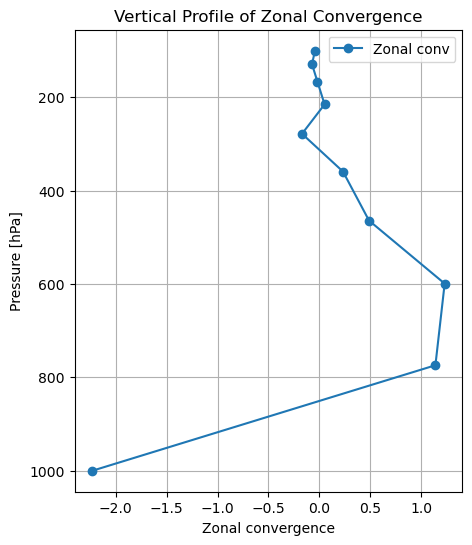

In [211]:
pressure = np.logspace(np.log10(1000), np.log10(100), num=10, dtype=int)

plt.figure(figsize=(5,6))

plt.plot(zonal_conv * 1000, pressure, marker="o", label="Zonal conv")

plt.gca().invert_yaxis()   # put 1000 hPa at bottom, 50 hPa at top

plt.xlabel("Zonal convergence")

plt.ylabel("Pressure [hPa]")

plt.title("Vertical Profile of Zonal Convergence")

plt.legend()

plt.grid(True)

plt.show()